**END-TO-END AI FOR SCIENCE · CRASH SIMULATION TRACK**

# Notebook1: GeoTransolver Architecture and Concepts

**Executed PhysicsNeMo architecture analysis · native VTP data · full 13,675-point mesh**

The architecture is traced from VTP arrays through the GeoTransolver context builder, GALE
blocks, and the three temporal wrappers. Executable cells inspect the public recipe and source
data; embedded figures show separate full-recipe reference results.

> The only model-training workflow in this notebook series is Notebook2's two-epoch,
> position-only one-shot demonstration. Longer training belongs in the PhysicsNeMo crash recipe.


## Workflow components

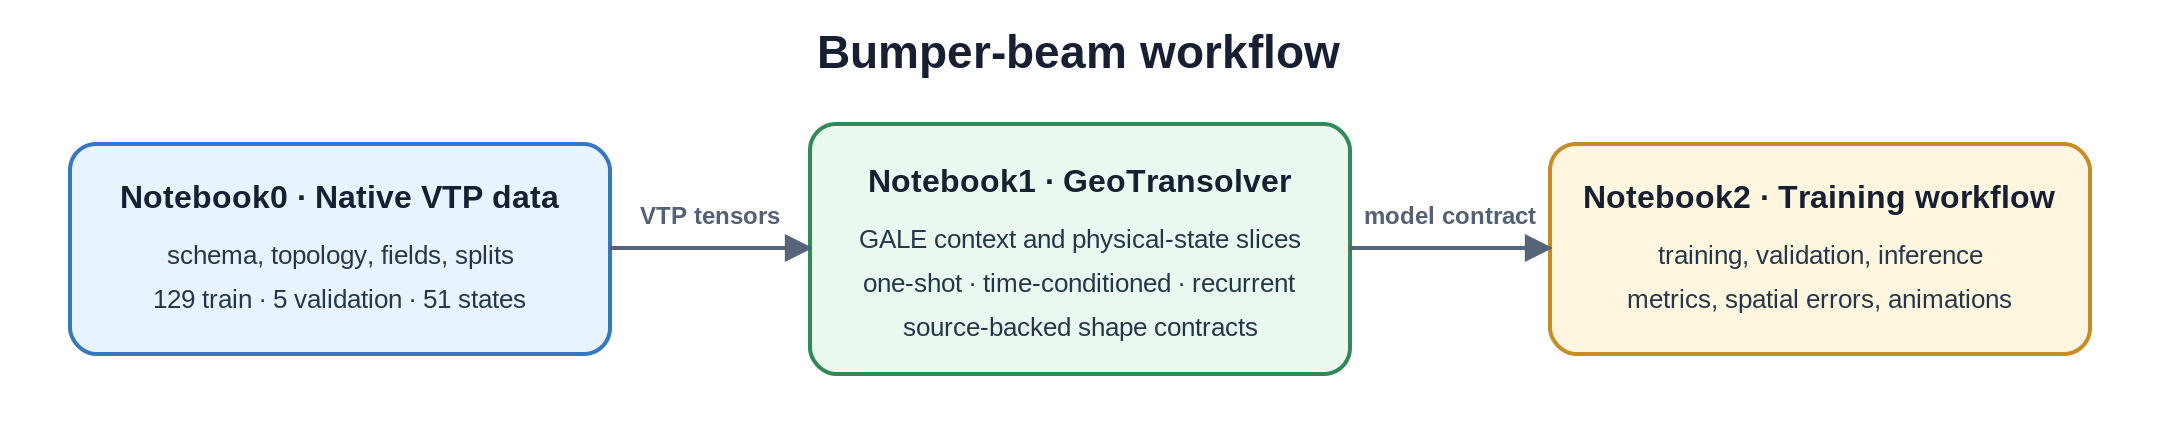

Notebook0 establishes the data contract, Notebook1 resolves the architecture and tensor paths, and
Notebook2 contains training histories, validation analysis, and exported prediction animations.


## 1. Runtime and source of truth

Notebook1 reads the mounted crash recipe and native VTP data. It does not locate scheduler run
directories, load user checkpoints, or expose a live model-inference switch.


In [1]:
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
from IPython.display import display
import json, os, re, sys, warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
import torch
import physicsnemo
from omegaconf import OmegaConf

def locate_recipe():
    candidates = []
    configured_recipe = os.environ.get("PHYSICSNEMO_CRASH_RECIPE")
    configured_root = os.environ.get("CRASH_PROJECT_ROOT")
    if configured_recipe:
        candidates.append(Path(configured_recipe).expanduser())
    if configured_root:
        candidates.append(
            Path(configured_root).expanduser()
            / "physicsnemo/examples/structural_mechanics/crash"
        )
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidates.append(base / "physicsnemo/examples/structural_mechanics/crash")
    for candidate in candidates:
        if (candidate / "train.py").is_file() and (candidate / "vtp_reader.py").is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        "PhysicsNeMo crash recipe not found. Set PHYSICSNEMO_CRASH_RECIPE or CRASH_PROJECT_ROOT."
    )

def locate_dataset():
    candidates = []
    configured = os.environ.get("BUMPER_BEAM_DATA_ROOT")
    if configured:
        candidates.append(Path(configured).expanduser())
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidates.extend([base / "datasets/bumper_beam", base / "data/bumper_beam"])
    candidates.append(Path("/workspace/datasets/bumper_beam"))
    for candidate in candidates:
        if (candidate / "train").is_dir() and (candidate / "validation").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Bumper-beam dataset not found. Set BUMPER_BEAM_DATA_ROOT before starting Jupyter."
    )


RECIPE_DIR = locate_recipe()
DATA_ROOT = locate_dataset()
CONFIG_DIR = RECIPE_DIR / "conf"
MODEL_CONFIG_PATHS = {
    "oneshot": CONFIG_DIR / "model/geotransolver_one_shot.yaml",
    "time_conditional": CONFIG_DIR / "model/geotransolver_time_conditional.yaml",
    "autoregressive": CONFIG_DIR / "model/geotransolver_autoregressive_rollout_training.yaml",
}
EXPERIMENT_CONFIG = CONFIG_DIR / "bumper_geotransolver_oneshot.yaml"

sys.path.insert(0, str(RECIPE_DIR))
from vtp_reader import load_vtp_file

required = [
    RECIPE_DIR / "rollout.py", RECIPE_DIR / "datapipe.py",
    DATA_ROOT / "validation/run1.vtp", DATA_ROOT / "global_features.json",
    EXPERIMENT_CONFIG, *MODEL_CONFIG_PATHS.values(),
]
for path in required:
    assert path.exists(), path

def package_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "not installed"

print(f"Python      : {sys.version.split()[0]}")
print(f"PhysicsNeMo : {getattr(physicsnemo, '__version__', package_version('nvidia-physicsnemo'))}")
print(f"PyTorch     : {torch.__version__}")
print(f"CUDA visible: {torch.cuda.device_count()} device(s)")
print("Recipe      : rollout.py, datapipe.py, and model configs found")
print("Dataset     : validation/run1.vtp and global_features.json found")


Python      : 3.12.3
PhysicsNeMo : 2.2.0
PyTorch     : 2.13.0a0+9186a08b2c.nv26.07
CUDA visible: 8 device(s)
Recipe      : rollout.py, datapipe.py, and model configs found
Dataset     : validation/run1.vtp and global_features.json found


## 2. Real bumper-beam tensor contract

One VTP file contains the reference mesh plus 51 time-indexed displacement vectors and two
51-state cell-field histories. `vtp_reader.py` reconstructs absolute positions and converts the
cell fields to point fields when they are configured as dynamic targets.


In [2]:
def natural_run_key(path):
    match = re.search(r"(\d+)$", Path(path).stem)
    return int(match.group(1)) if match else Path(path).stem

train_files = sorted((DATA_ROOT / "train").glob("*.vtp"), key=natural_run_key)
validation_files = sorted((DATA_ROOT / "validation").glob("*.vtp"), key=natural_run_key)
assert len(train_files) == 129 and len(validation_files) == 5

raw_mesh = pv.read(validation_files[0])
displacement_names = sorted(
    [n for n in raw_mesh.point_data if n.startswith("displacement_t")],
    key=lambda n: float(n.rsplit("t", 1)[1]),
)
peeq_names = sorted(
    [n for n in raw_mesh.cell_data if n.startswith("cell_effective_plastic_strain_t")],
    key=lambda n: float(n.rsplit("t", 1)[1]),
)
stress_names = sorted(
    [n for n in raw_mesh.cell_data if n.startswith("cell_stress_vm_t")],
    key=lambda n: float(n.rsplit("t", 1)[1]),
)
times = np.array([float(n.rsplit("t", 1)[1]) for n in displacement_names])
assert len(displacement_names) == len(peeq_names) == len(stress_names) == 51
assert np.allclose(np.diff(times), 0.005)

contract = pd.DataFrame([
    ["simulations", 129, 5, "one VTP per run"],
    ["mesh", raw_mesh.n_points, raw_mesh.n_cells, "quad surface"],
    ["displacement", len(displacement_names), 3, "point vectors"],
    ["effective plastic strain", len(peeq_names), 1, "cell scalars"],
    ["von-Mises stress", len(stress_names), 1, "cell scalars"],
], columns=["quantity", "count / train", "validation / components", "representation"])
display(contract)
print(f"Time interval : {times[0]:.3f} ... {times[-1]:.3f} s, dt={np.diff(times)[0]:.3f} s")
print(f"Point arrays  : {len(raw_mesh.point_data)}")
print(f"Cell arrays   : {len(raw_mesh.cell_data)}")


,quantity,count / train,validation / components,representation
0,simulations,129,5,one VTP per run
1,mesh,13675,13626,quad surface
2,displacement,51,3,point vectors
3,effective plastic strain,51,1,cell scalars
4,von-Mises stress,51,1,cell scalars


Time interval : 0.000 ... 0.250 s, dt=0.005 s
Point arrays  : 52
Cell arrays   : 102


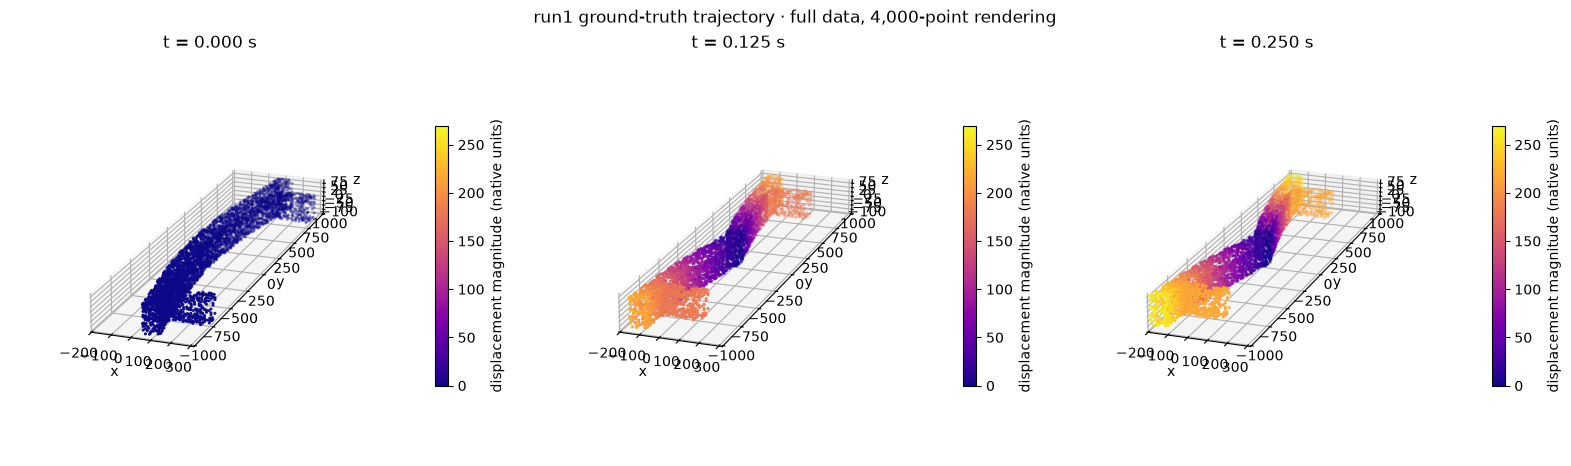

In [3]:
pos_raw, mesh_connectivity, point_data = load_vtp_file(validation_files[0])
assert pos_raw.shape == (51, 13675, 3)
plot_ids = np.sort(np.random.default_rng(7).choice(pos_raw.shape[1], 4000, replace=False))
lo, hi = pos_raw.reshape(-1, 3).min(0), pos_raw.reshape(-1, 3).max(0)
aspect = np.maximum(hi - lo, 1e-9)
umax = np.linalg.norm(pos_raw - pos_raw[0], axis=2).max()

fig = plt.figure(figsize=(16, 4.8))
for column, frame in enumerate([0, 25, 50], 1):
    xyz = pos_raw[frame]
    umag = np.linalg.norm(xyz - pos_raw[0], axis=1)
    ax = fig.add_subplot(1, 3, column, projection="3d")
    sc = ax.scatter(*xyz[plot_ids].T, c=umag[plot_ids], s=1.5,
                    cmap="plasma", vmin=0, vmax=umax)
    ax.set(xlim=(lo[0], hi[0]), ylim=(lo[1], hi[1]), zlim=(lo[2], hi[2]),
           xlabel="x", ylabel="y", zlabel="z", title=f"t = {times[frame]:.3f} s")
    ax.set_box_aspect(aspect)
    ax.view_init(elev=20, azim=-70)
    fig.colorbar(sc, ax=ax, shrink=0.62, label="displacement magnitude (native units)")
fig.suptitle("run1 ground-truth trajectory · full data, 4,000-point rendering")
fig.tight_layout()
plt.show()


## 3. VTP trajectory to `SimSample`

Position statistics are computed from the training split and applied coordinate-wise:

$$\tilde{\mathbf{x}}_t=(\mathbf{x}_t-\boldsymbol\mu_x)/(\boldsymbol\sigma_x+\epsilon).$$

The position-only target removes the reference state and transposes the remaining trajectory:

$$\texttt{coords}=\tilde{\mathbf{x}}_0\in\mathbb{R}^{N\times3},\qquad
\texttt{node\_target}=\tilde{\mathbf{x}}_{1:51}^{\mathsf T}\in\mathbb{R}^{N\times50\times3}.$$

No per-node static feature is configured. `thickness_scale` remains a global conditioning value;
the raw point array named `thickness` is zero throughout this supplied dataset.


In [4]:
coords = torch.as_tensor(pos_raw[0], dtype=torch.float32)
target_all = torch.as_tensor(pos_raw[1:], dtype=torch.float32).transpose(0, 1)
empty_features = coords.new_zeros((coords.shape[0], 0))
global_features = json.loads((DATA_ROOT / "global_features.json").read_text())["run1"]

shapes = pd.DataFrame([
    ["coords", tuple(coords.shape), "reference positions; normalized by the training datapipe"],
    ["features", tuple(empty_features.shape), "no static node channels"],
    ["node_target", tuple(target_all.shape), "50 future positions; normalized by the datapipe"],
    ["global_features", (len(global_features),), str(global_features)],
], columns=["SimSample field", "shape", "content"])
display(shapes)
print("Normalization changes values, not the tensor shapes shown here.")


,SimSample field,shape,content
0,coords,"(13675, 3)",reference positions; normalized by the trainin...
1,features,"(13675, 0)",no static node channels
2,node_target,"(13675, 50, 3)",50 future positions; normalized by the datapipe
3,global_features,"(3,)","{'velocity_x': -5.0, 'thickness_scale': 1.0, '..."


Normalization changes values, not the tensor shapes shown here.


### Position-only and five-channel recipe contracts

| Output contract | Position-only configuration | One-shot / time-conditioned five-channel configuration |
|---|---:|---:|
| position | 3 channels | 3 channels |
| effective plastic strain | excluded | 1 channel |
| von-Mises stress | excluded | 1 channel |
| per-time feature count | `3` | `5` |
| one-shot `out_dim` | `50×3 = 150` | `50×5 = 250` |
| time-conditioned `out_dim` | `3` | `5` |

The unmodified autoregressive wrapper integrates three acceleration channels and returns position
only. Adding stress and strain to that wrapper requires a separate non-integrated output path.


## 4. GeoTransolver execution path

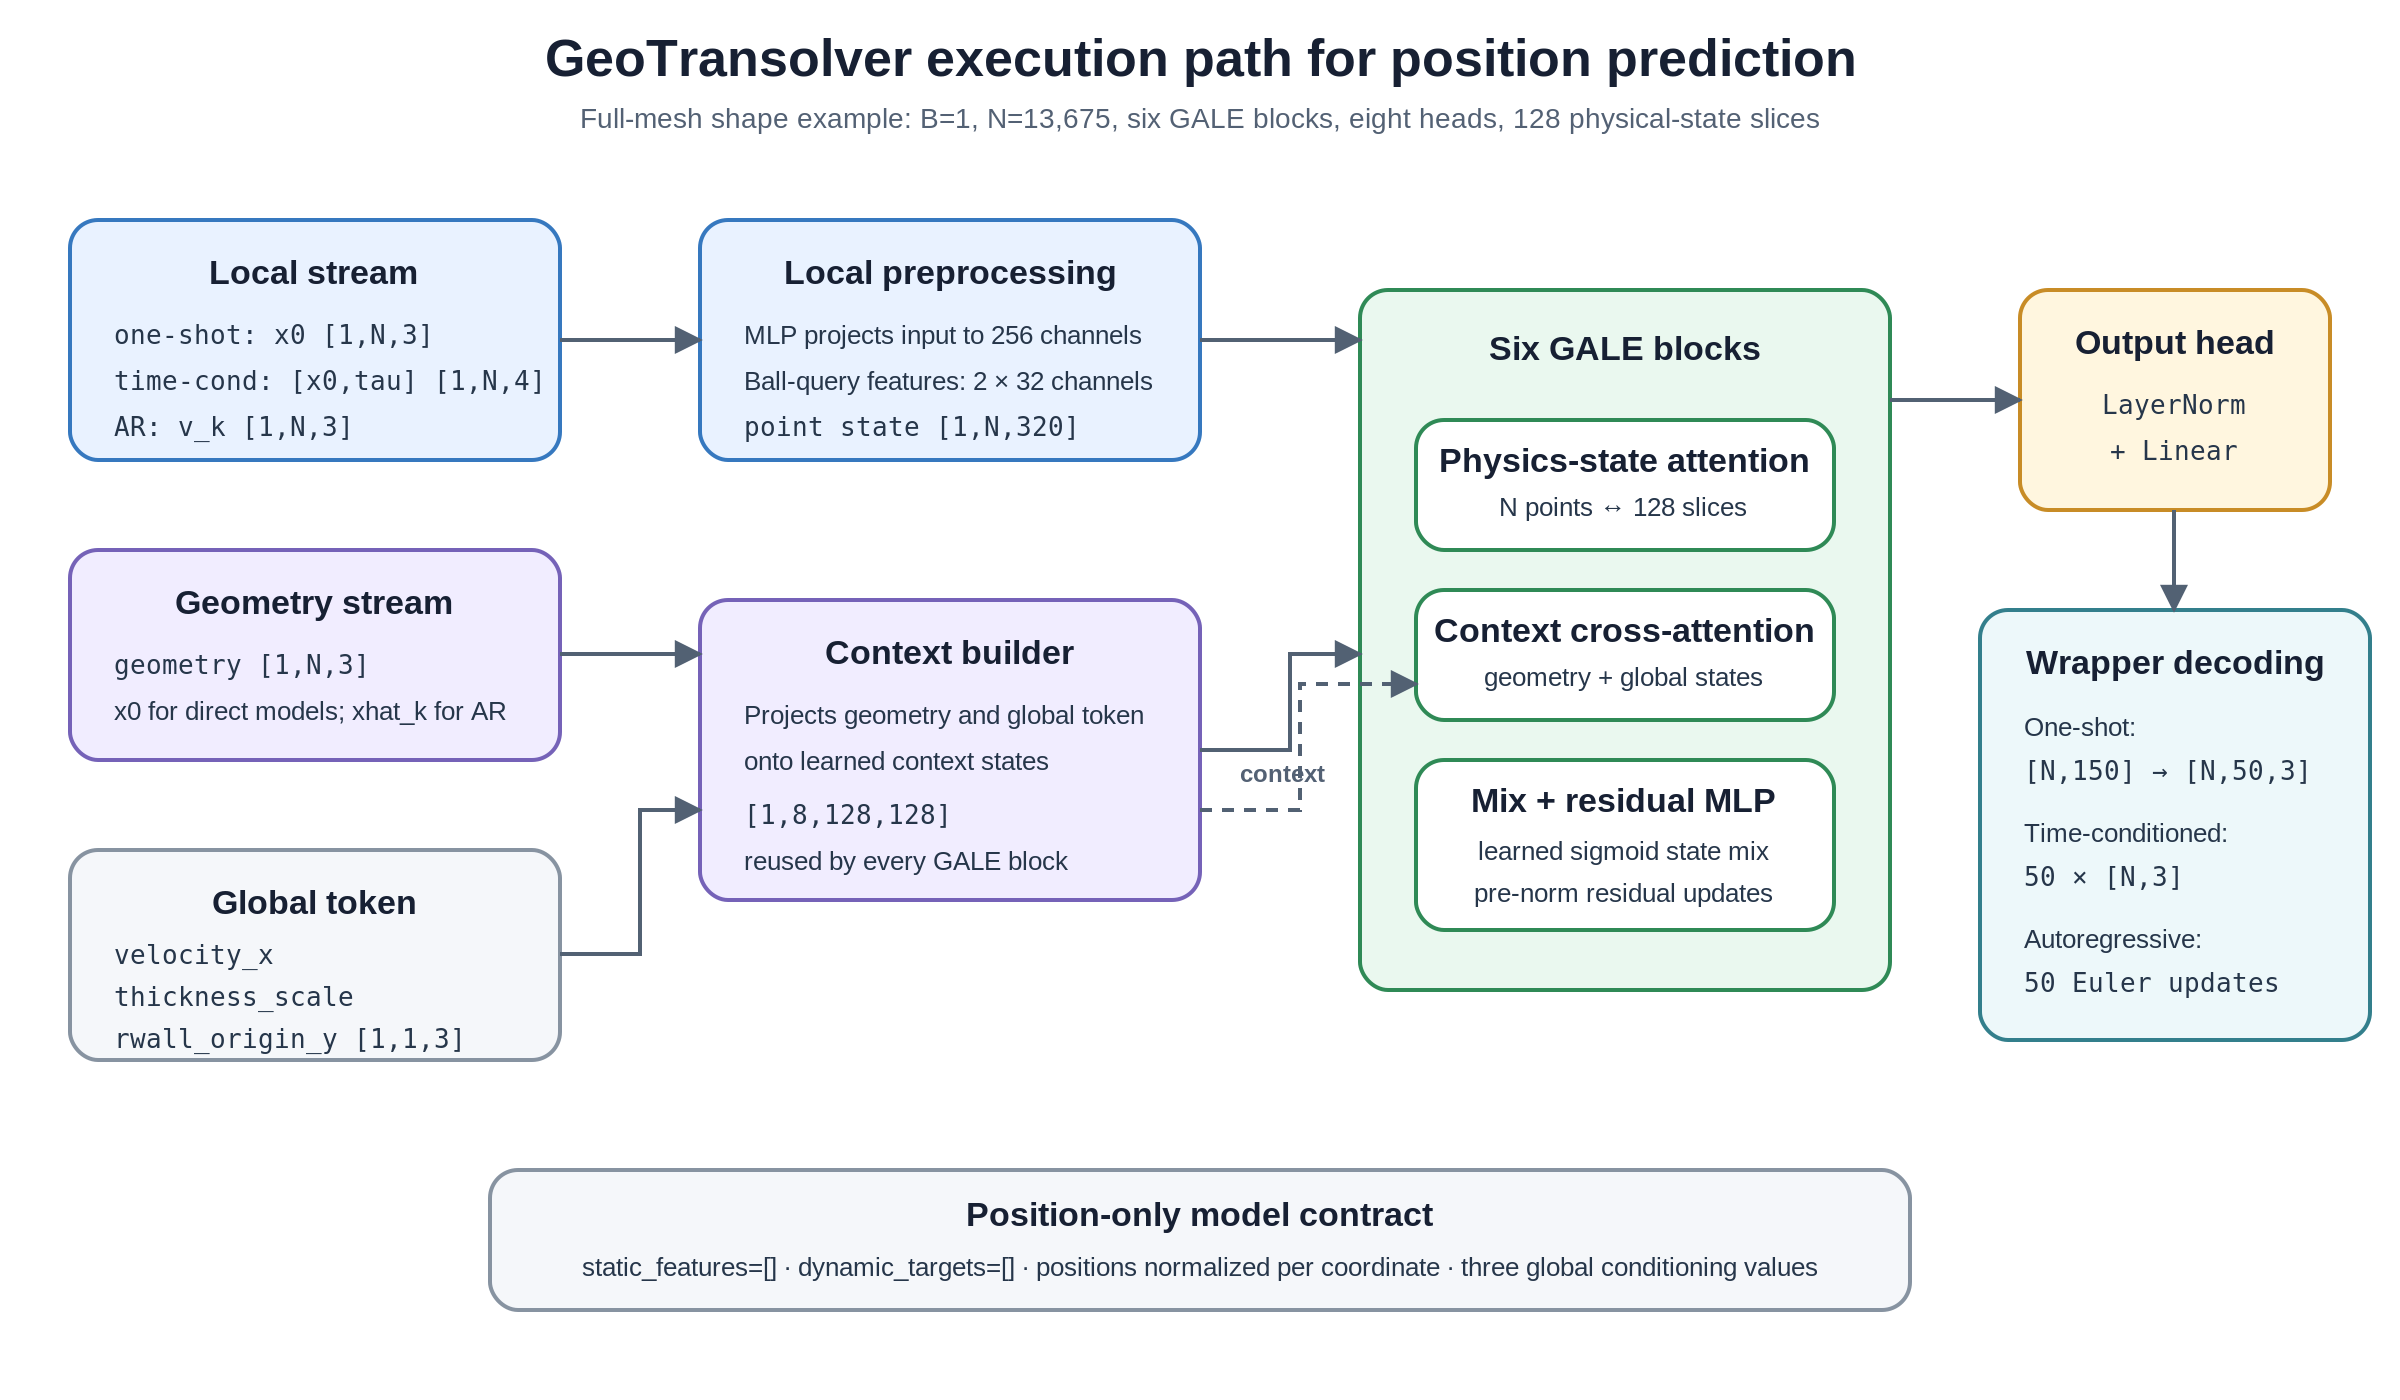

Geometry and the three global values are projected to context states once per forward call.
Every GALE block receives those context states. With local ball-query features enabled, the
256-channel input projection is augmented by two 32-channel neighborhoods, producing the measured
320-channel point representation.


In [5]:
source_model_configs = {
    method: OmegaConf.load(path) for method, path in MODEL_CONFIG_PATHS.items()
}
future_steps = len(times) - 1
position_contracts = {
    "oneshot": {"sample_type": "all_time_steps", "functional_dim": 3, "out_dim": future_steps * 3},
    "time_conditional": {"sample_type": "one_time_step", "functional_dim": 4, "out_dim": 3},
    "autoregressive": {"sample_type": "all_time_steps", "functional_dim": 3, "out_dim": 3},
}

config_rows = []
for method, model_cfg in source_model_configs.items():
    contract = position_contracts[method]
    config_rows.append({
        "method": method,
        "wrapper from recipe": model_cfg._target_.split(".")[-1],
        "sample type": contract["sample_type"],
        "local input width": contract["functional_dim"],
        "position head width": contract["out_dim"],
        "geometry width": model_cfg.geometry_dim,
        "GALE blocks": model_cfg.n_layers,
        "physical-state slices": model_cfg.slice_num,
    })
display(pd.DataFrame(config_rows))
print("Position head widths are derived from the 50 future states in the inspected VTP.")


,method,wrapper from recipe,sample type,local input width,position head width,geometry width,GALE blocks,physical-state slices
0,oneshot,GeoTransolverOneShot,all_time_steps,3,150,3,6,128
1,time_conditional,GeoTransolverTimeConditional,one_time_step,4,3,3,6,128
2,autoregressive,GeoTransolverAutoregressiveRolloutTraining,all_time_steps,3,3,3,6,128


Position head widths are derived from the 50 future states in the inspected VTP.


## 5. Geometry-Aware Latent Embeddings (GALE)

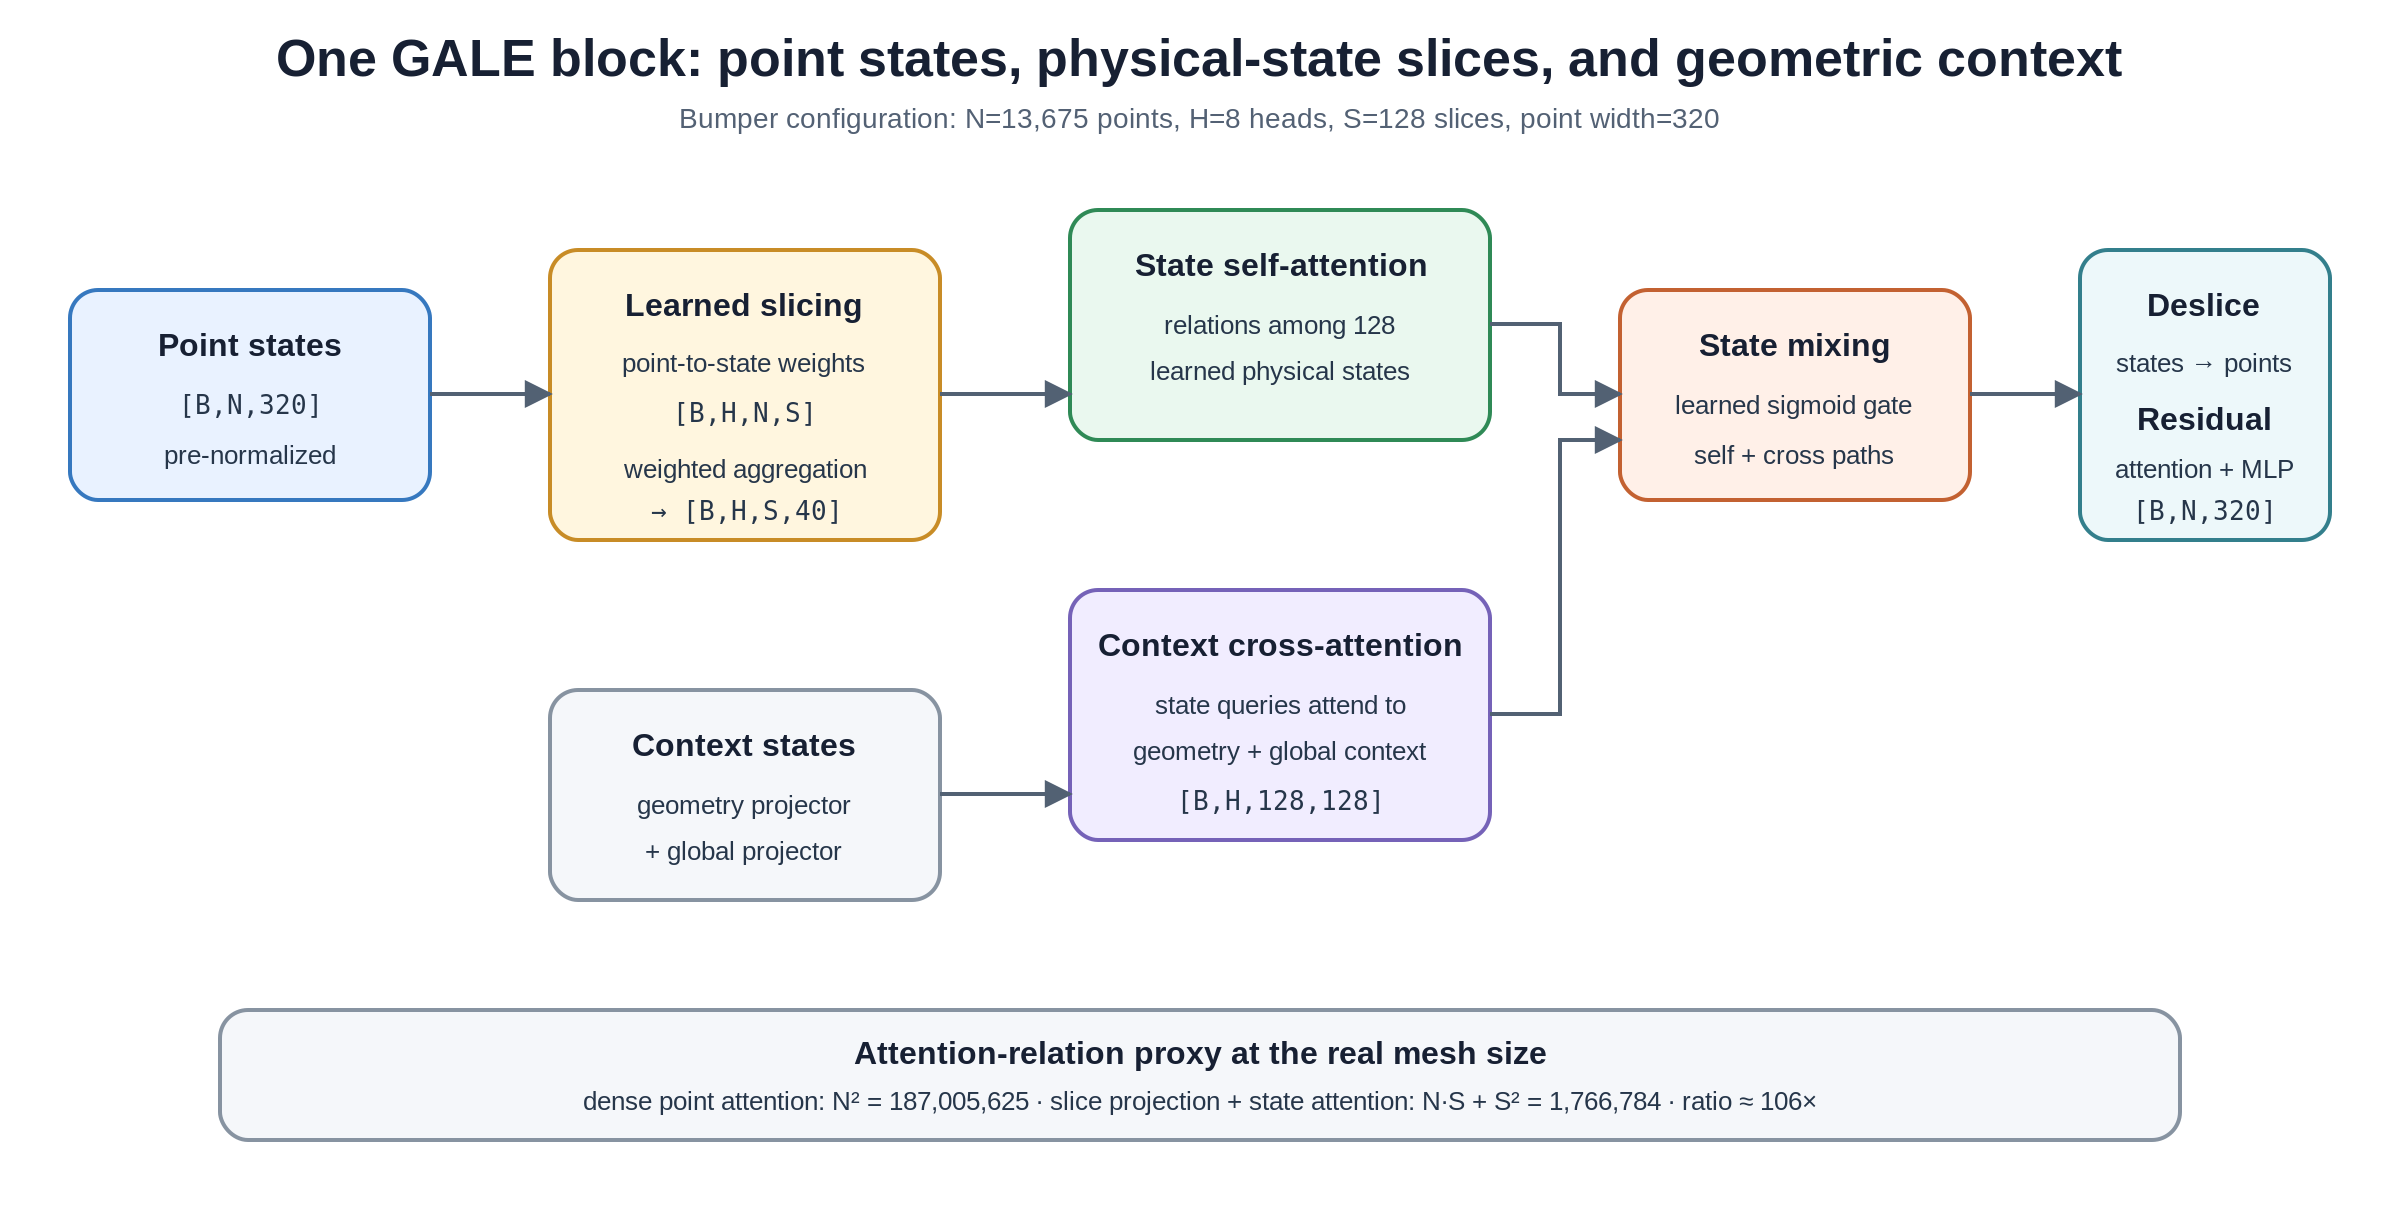

GALE extends physics-state attention with cross-attention to geometry/global context. State
self-attention and context cross-attention are blended by a learned sigmoid gate, desliced back to
points, and followed by residual attention and MLP updates. The gate is a learned state-mixing
coefficient; it is not a verified spatial map of flanges, welds, or plastic zones.


,relation proxy,scalar entries / head,FP32 MiB / head
0,Dense point self-attention,187005625,713.369846
1,Point-to-slice + slice self-attention,1766784,6.739746


Relation-count ratio at N=13,675, S=128: 105.8×


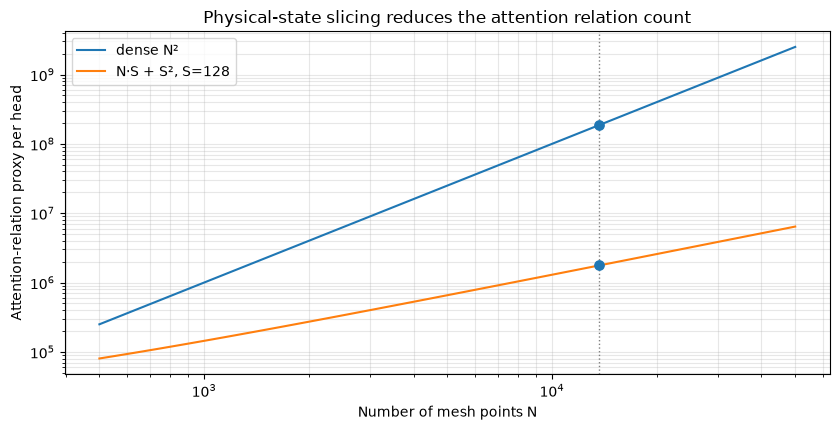

This relation count is not an end-to-end runtime or memory speedup measurement.


In [6]:
N_real = raw_mesh.n_points
slices = int(source_model_configs["oneshot"].slice_num)
dense_relations = N_real**2
sliced_relations = N_real * slices + slices**2
relation_table = pd.DataFrame([
    ["Dense point self-attention", dense_relations, dense_relations * 4 / 2**20],
    ["Point-to-slice + slice self-attention", sliced_relations, sliced_relations * 4 / 2**20],
], columns=["relation proxy", "scalar entries / head", "FP32 MiB / head"])
display(relation_table)
print(f"Relation-count ratio at N={N_real:,}, S={slices}: {dense_relations/sliced_relations:.1f}×")

node_counts = np.unique(np.geomspace(500, 50000, 80).astype(int))
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.loglog(node_counts, node_counts**2, label="dense N²")
ax.loglog(node_counts, node_counts*slices + slices**2, label=f"N·S + S², S={slices}")
ax.scatter([N_real, N_real], [dense_relations, sliced_relations], s=45, zorder=4)
ax.axvline(N_real, color="0.5", linestyle=":", linewidth=1)
ax.set(xlabel="Number of mesh points N", ylabel="Attention-relation proxy per head",
       title="Physical-state slicing reduces the attention relation count")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()
print("This relation count is not an end-to-end runtime or memory speedup measurement.")


## 6. Temporal wrappers

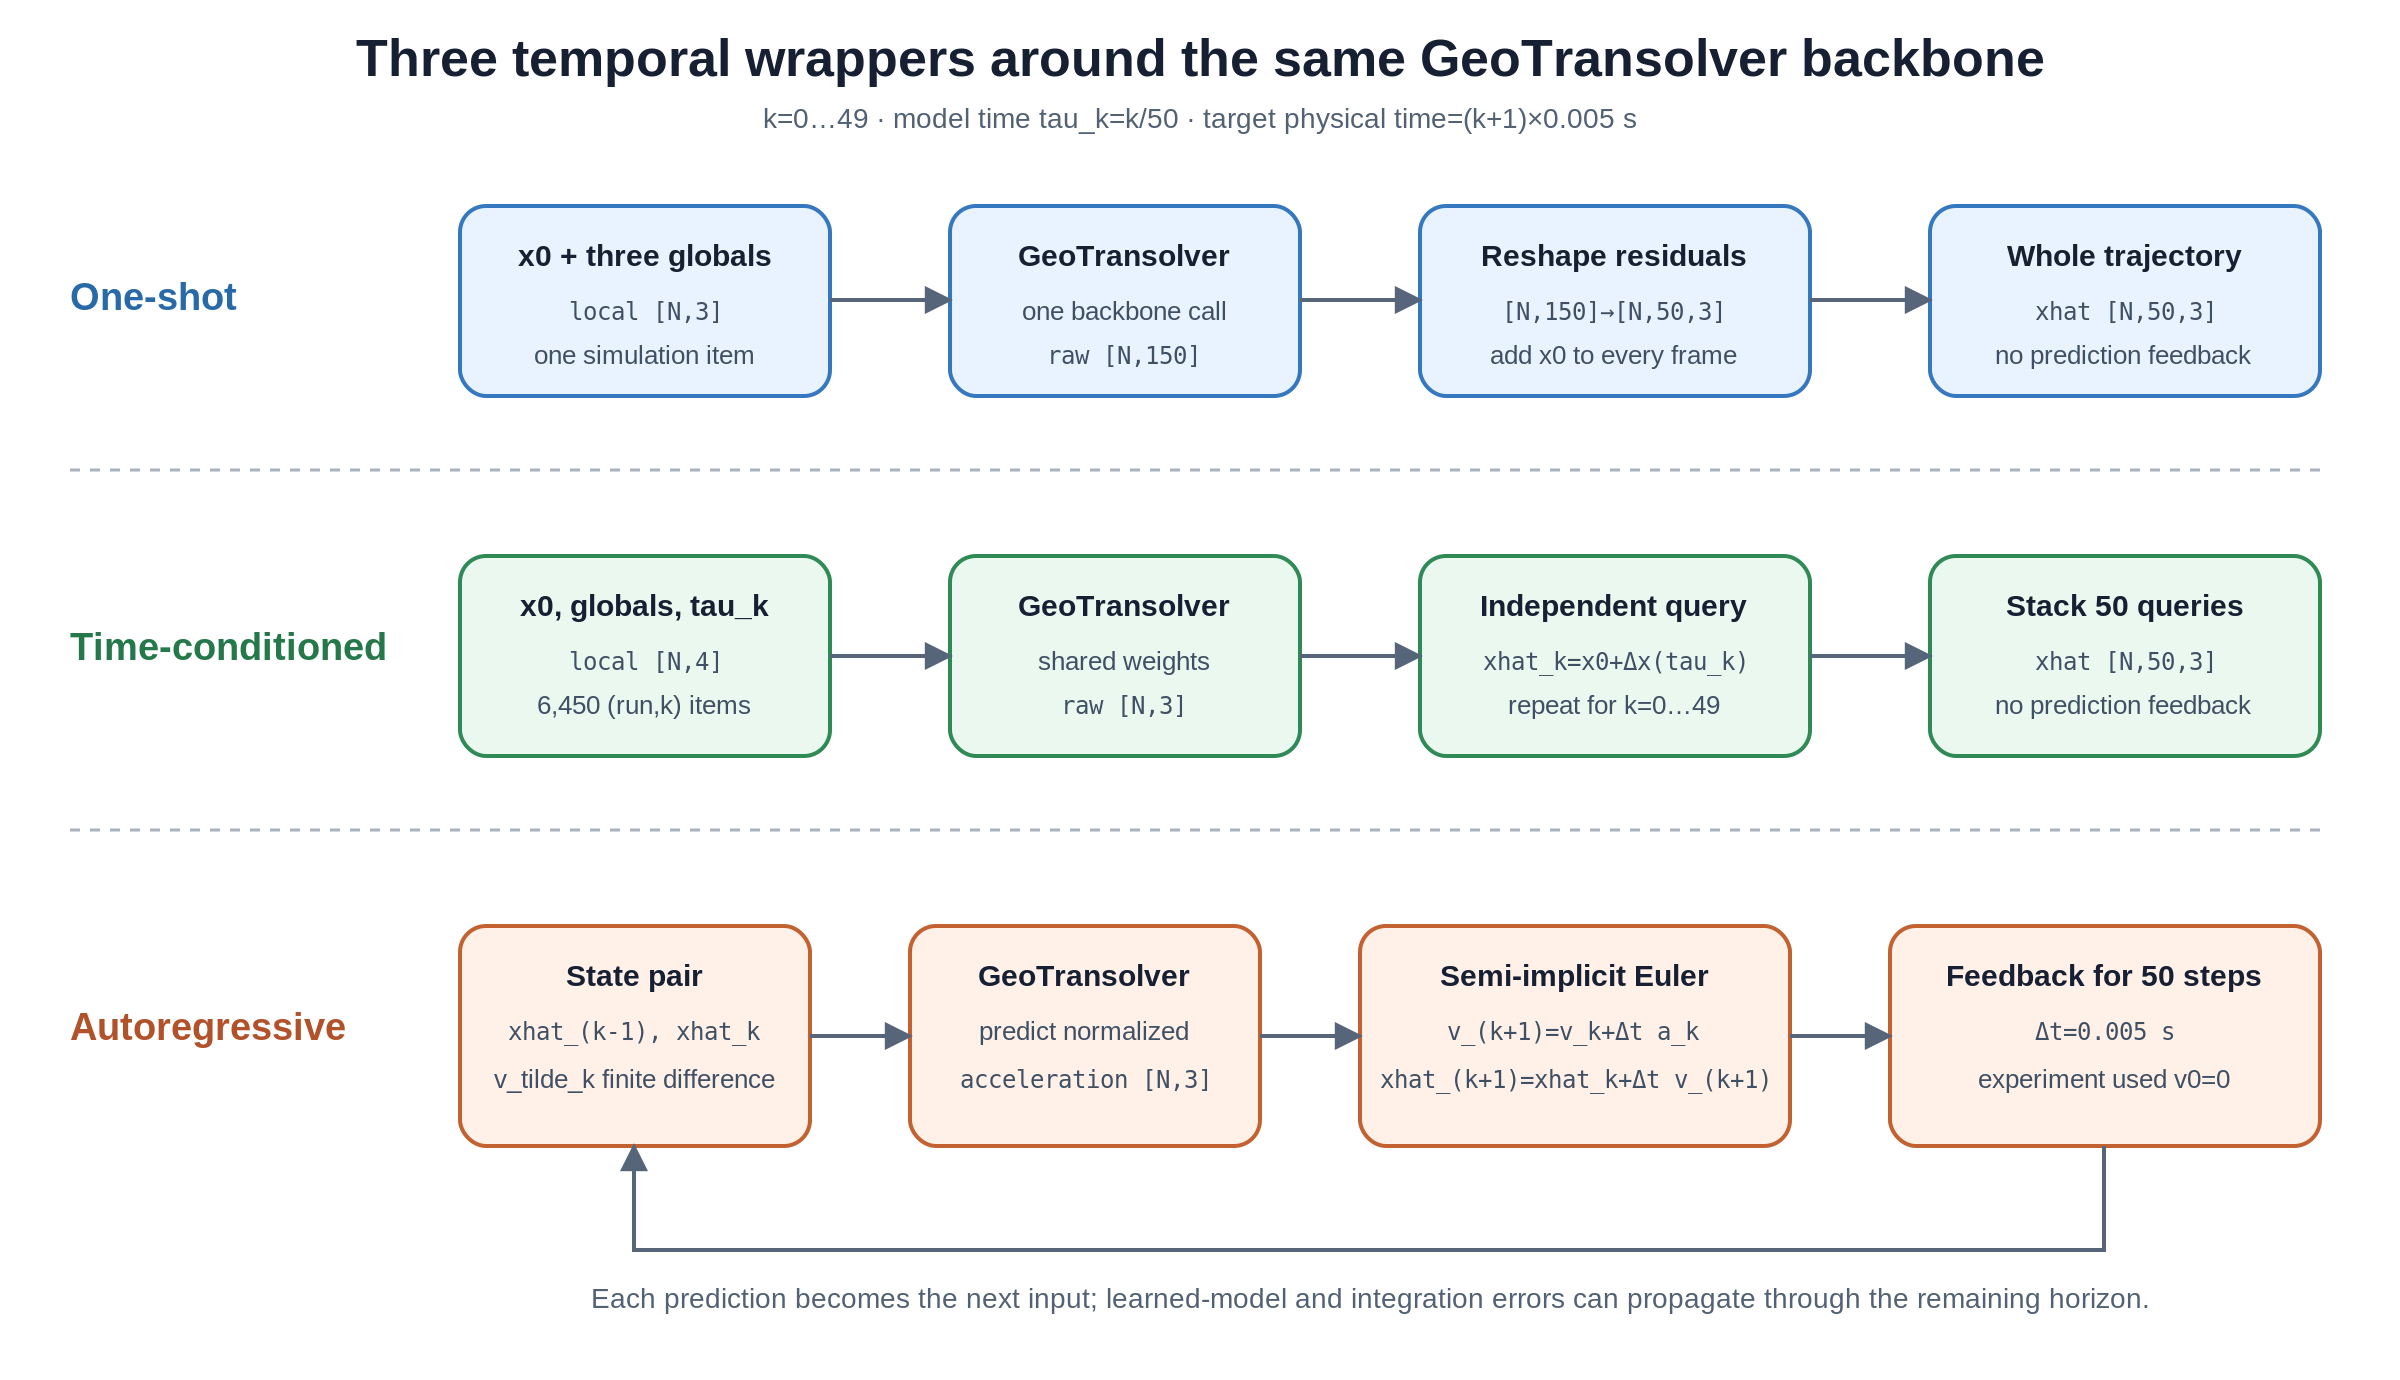

One-shot and time-conditioned are direct temporal parameterizations. The autoregressive wrapper
adds an explicit semi-implicit Euler-shaped update and feeds each predicted position into the next
step. All three call the same GeoTransolver backbone class with different local inputs and heads.


In [7]:
# Compact equivalents of the decoding operations in rollout.py.
def decode_one_shot(raw, x0, steps=50):
    prediction = raw.reshape(x0.shape[0], steps, -1).clone()
    prediction[..., :3] += x0[:, None, :]
    return prediction

def time_query(k, steps=50, dt=0.005):
    return k / steps, (k + 1) * dt

def semi_implicit_euler(x_now, velocity, acceleration, dt=0.005):
    velocity_next = velocity + dt * acceleration
    position_next = x_now + dt * velocity_next
    return position_next, velocity_next

display(pd.DataFrame(
    [(k, *time_query(k)) for k in (0, 24, 49)],
    columns=["target index k", "model time τ=k/50", "physical target time (s)"],
))


,target index k,model time τ=k/50,physical target time (s)
0,0,0.00,0.005
1,24,0.48,0.125
2,49,0.98,0.250


| Method | Sample type | Dataset item | Local input | Head per call | Calls per trajectory | Feedback |
|---|---|---|---|---|---|---|
| One-shot | `all_time_steps` | one simulation | $x_0$ | all future positions | one | none |
| Time-conditioned | `one_time_step` | one simulation–time pair | $x_0, \tau_k$ | one queried position | one per requested time | none |
| Autoregressive | `all_time_steps` | one simulation | current velocity/state | one update | one per rollout step | predicted state |

These contracts come from the rollout classes and resolved Hydra configurations shown above.

## 7. Reference behavior from full recipe runs

The following embedded curve and animation summarize separate, completed recipe experiments on
the same validation trajectory. Notebook1 does not load or execute those models. The executable
content here remains focused on architecture and tensor contracts.


### Run1 position error through time

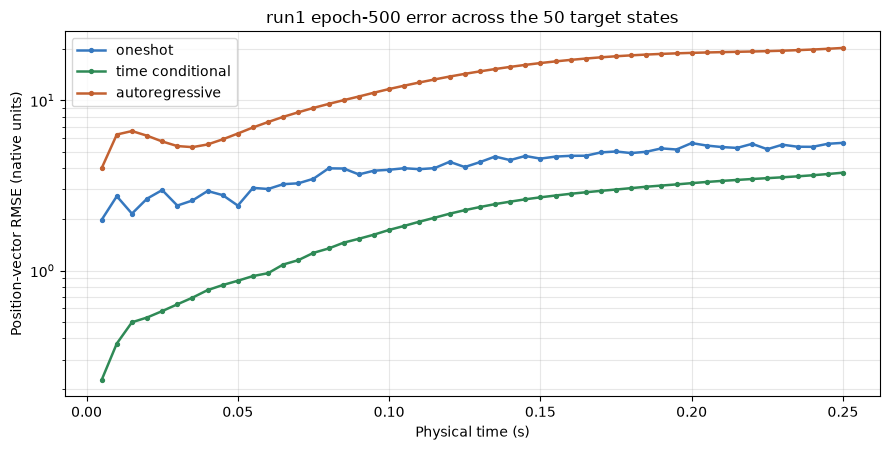

This embedded reference curve comes from full recipe runs on the same validation case (`run1`).
Each point is the Euclidean position RMSE over all 13,675 mesh points, in native dataset length
units. It is not generated by a checkpoint path in this notebook.


## 8. Full-mesh reference comparison

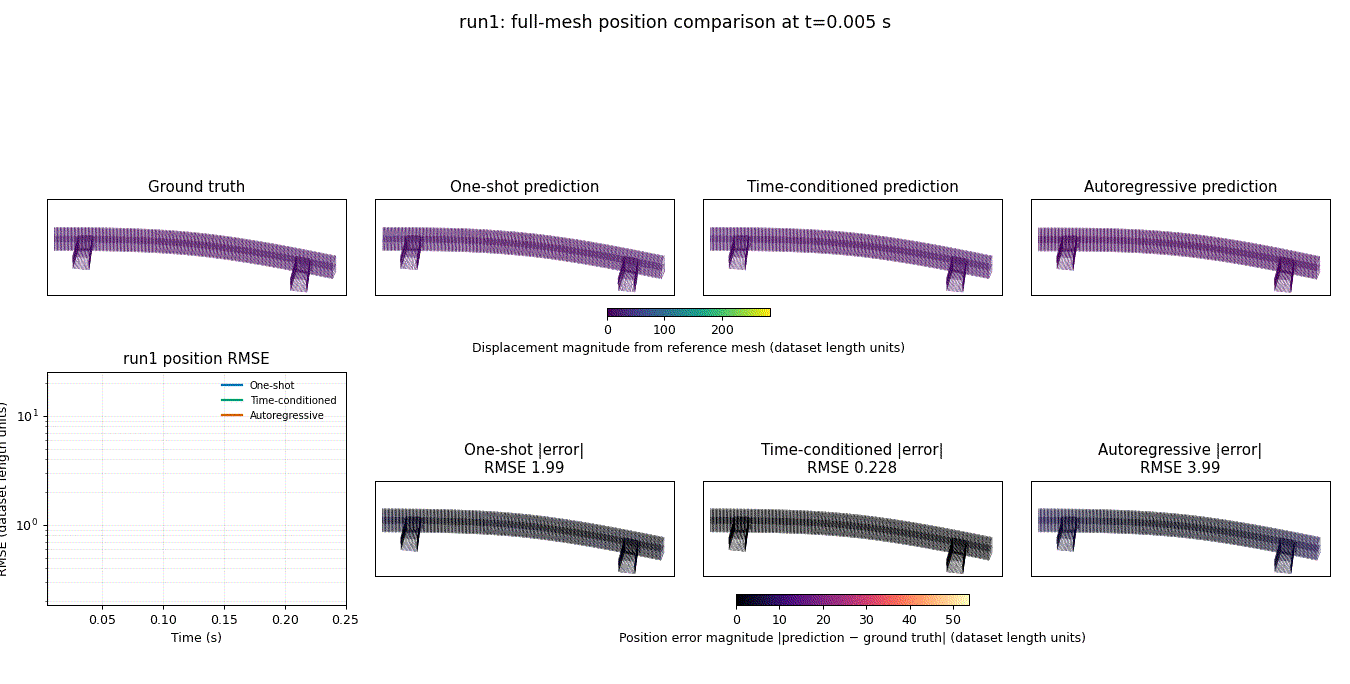

The animation contains all 13,675 points and 50 target states from `0.005` through `0.250 s`.
It is embedded reference evidence from separate full recipe runs; Notebook2 contains the only
executable training and inference workflow in this series.


## 9. Mechanism and observed behavior

The wrapper structure explains call count and feedback, but it does not determine accuracy by
itself. The embedded reference evidence illustrates one measured experiment; use the crash recipe
to reproduce or extend that comparison.


### Mechanism versus evidence

- One-shot uses one wide output head and one backbone call. Its errors are not fed back, but
  late-time error still rises because later crash states are harder to approximate.
- Time-conditioned uses a narrow head and independent time queries. It has the lowest error on
  every recorded validation run/frame comparison in this experiment.
- Autoregressive uses repeated acceleration predictions and numerical updates. Its state feedback
  permits error propagation, and the measured long-horizon drift is largest.
- The autoregressive result also depends on the experimental `initial_vel=0.0` setting; it is not
  a calibrated per-run initial velocity.

## 10. Geometry, global conditioning, and unused physical fields

The three global values are supplied as a single context token. Point `thickness` is not used as
a static feature. PEEQ and stress are available after cell-to-point conversion but are excluded by
`dynamic_targets=[]` in the completed comparison.


In [8]:
all_feature_rows = pd.DataFrame.from_dict(
    json.loads((DATA_ROOT / "global_features.json").read_text()), orient="index")
train_ids = {p.stem for p in train_files}
train_feature_rows = all_feature_rows.loc[sorted(train_ids, key=lambda x: int(x[3:]))]
display(train_feature_rows.agg(["min", "max", "nunique"]).T)

thickness = np.asarray(raw_mesh.point_data["thickness"])
print(f"Raw point thickness range: {thickness.min():.3g} ... {thickness.max():.3g}")
experiment_cfg = OmegaConf.load(EXPERIMENT_CONFIG)
print("Configured static_features:", list(experiment_cfg.datapipe.static_features))
print("Configured global_features:", list(experiment_cfg.datapipe.global_features))


,min,max,nunique
velocity_x,-7.0,-3.0,3.0
thickness_scale,0.7,1.3,3.0
rwall_origin_y,0.0,240.0,3.0


Raw point thickness range: 0 ... 0
Configured static_features: []
Configured global_features: ['velocity_x', 'thickness_scale', 'rwall_origin_y']


## 11. Evaluation assumptions and limitations

- All tensor contracts use the full 13,675-node mesh; only Matplotlib rendering subsamples points.
- The five `test/` VTPs duplicate the validation files, so no independent test claim is available.
- The reference RMSE figure and animation are embedded outputs from separate recipe runs and are
  not recomputed in this architecture notebook.
- `frame_000` represents the first target at `0.005 s`; `frame_049` represents `0.250 s`.
- The position-only reference results cannot support conclusions about predicted stress or
  plastic strain.


## 12. Conclusions

GeoTransolver maps irregular-mesh point states to learned physical-state slices, combines state
self-attention with geometry/global cross-attention in six GALE blocks, and projects the point
states through a task-specific output head.

The temporal wrappers change the contract around that shared backbone. One-shot produces the
trajectory in one call, time-conditioned evaluates independent time queries, and autoregressive
prediction uses a state-feedback update. Notebook2 demonstrates the one-shot training path; full
experiments for any method belong in the PhysicsNeMo crash recipe.

**Sources:** mounted `rollout.py`, `datapipe.py`, `vtp_reader.py`, public recipe configurations,
native VTP data, and embedded reference figures from separate recipe runs.
